#**QR-code ссылка на репозиторий в [Github](https://github.com/kubenet/ML_course)**

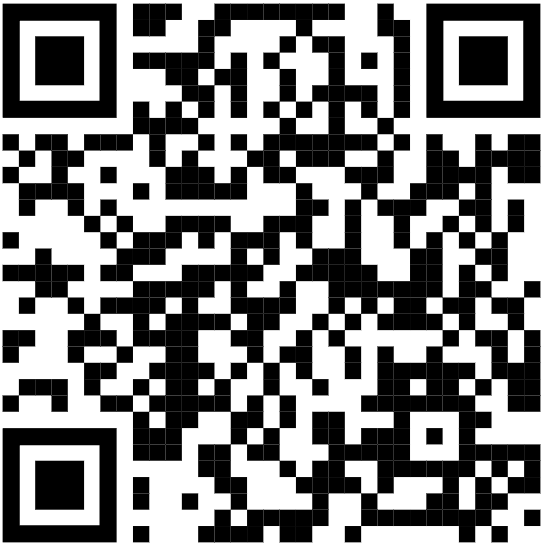

# Практическая работа №4: Регуляризация, Переобучение и Отбор Признаков

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

---

# Практика №4: Регуляризация, Переобучение и Отбор Признаков

## 🎯 Цели занятия
1.  Изучить эффект переобучения на примере полиномиальной регрессии.
2.  Понять разницу между $L_1$ (Lasso) и $L_2$ (Ridge) регуляризацией.
3.  Научиться подбирать гиперпараметры через кросс-валидацию.
4.  Проанализировать устойчивость отбора признаков на реальных данных.

---

## 📚 Теоретический блок 1:Bias-Variance Tradeoff и Полиномиальная регрессия

**Концепция:**
Модель машинного обучения стремится минимизировать ошибку обобщения. Она складывается из:
$$ \text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error} $$

*   **Низкая степень полинома:** Высокое смещение (Bias), модель слишком простая (недообучение).
*   **Высокая степень полинома:** Высокая дисперсия (Variance), модель подстраивается под шум (переобучение).

**Регуляризация:**
Чтобы контролировать сложность модели, мы добавляем штрафной член к функции потерь (Loss Function):
*   **Ridge ($L_2$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} \theta_j^2$. Сжимает веса, но не обнуляет их.
*   **Lasso ($L_1$):** $J(\theta) = \text{MSE}(\theta) + \alpha \sum_{j=1}^{n} |\theta_j|$. Может обнулять веса, выполняя отбор признаков.

> ⚠️ **Важно:** Перед применением Ridge и Lasso данные необходимо масштабировать (Standardization), иначе штраф будет применяться неравномерно к признакам с разными масштабами.




















---

## 💻 Практический блок 1: Генерация данных и Кривые обучения






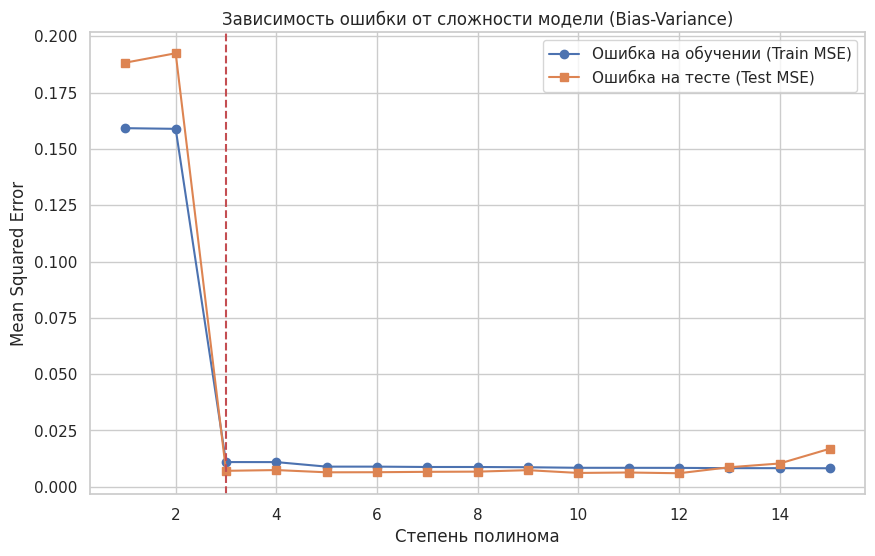

In [1]:
# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Настройка стилей для графиков
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Генерация синтетических данных
np.random.seed(42)
n_samples = 100
X_syn = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
# Истинная зависимость: синусоида + шум
y_syn = np.sin(X_syn.ravel()) + np.random.normal(0, 0.1, n_samples)

# Разделение на train и test
X_train_syn, X_test_syn, y_train_syn, y_test_syn = train_test_split(
    X_syn, y_syn, test_size=0.3, random_state=42
)
# Разделение данных на обучающую (70%) и тестовую (30%) выборки. Тестовая выборка имитирует новые, невиданные данные для оценки обобщающей способности модели.

# 2. Построение кривых обучения для степеней 1-15
degrees = range(1, 16)
train_errors, test_errors = [], []


# Для каждой степени полинома (от 1 до 15):
# Создаются полиномиальные признаки
# Данные масштабируются (критично для сравнения с Ridge/Lasso)
# Обучается линейная регрессия
# Вычисляется MSE на train и test
for d in degrees:
    # Пайплайн: Полином -> Масштабирование -> Линейная регрессия
    # Примечание: Для обычной регрессии масштабирование полиномов не всегда критично,
    # но для сравнения с Ridge/Lasso введем его сразу для единообразия.
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lin_reg', LinearRegression())
    ])

    model.fit(X_train_syn, y_train_syn)

    y_train_pred = model.predict(X_train_syn)
    y_test_pred = model.predict(X_test_syn)

    train_errors.append(mean_squared_error(y_train_syn, y_train_pred))
    test_errors.append(mean_squared_error(y_test_syn, y_test_pred))

# Визуализация
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_errors, label='Ошибка на обучении (Train MSE)', marker='o')
plt.plot(degrees, test_errors, label='Ошибка на тесте (Test MSE)', marker='s')
plt.xlabel('Степень полинома')
plt.ylabel('Mean Squared Error')
plt.title('Зависимость ошибки от сложности модели (Bias-Variance)')
plt.legend()
plt.axvline(x=3, color='r', linestyle='--', label='Примерная оптимальная сложность')
plt.show()

###График: Ошибка на обучении vs Ошибка на тесте

###Визуальная интерпретация:
- Синяя линия (Train): Монотонно убывает, стремится к нулю
- Оранжевая линия (Test): U-образная кривая с минимумом при степени 3-5
- Разрыв (Gap): Чем больше разрыв между линиями, тем сильнее переобучение

###Как мы это используем
- Выбор оптимальной сложности модели: Находим степень полинома, где ошибка на тесте минимальна.
- Диагностика переобучения: Если Train MSE << Test MSE → модель запоминает шум.
- Обоснование регуляризации: Показываем, что простое увеличение сложности ухудшает обобщение.

"Эксперимент демонстрирует классический `Bias-Variance Tradeoff`: увеличение сложности модели снижает смещение, но увеличивает дисперсию, что приводит к росту ошибки обобщения после определённого порога."

### 🧠 Комментарий:
Обратите внимание на график. Ошибка на обучении монотонно убывает (модель запоминает данные). Ошибка на тесте сначала падает, а затем растет после определенной степени (обычно 3-5 для синуса). Это точка **переобучения**.

##Выводы:

- Сложность ≠ Качество - модель 15-й степени хуже модели 4-й степени на новых данных
- Нужен баланс - оптимальная степень полинома соответствует минимуму Test MSE
- Train MSE ненадёжен - нельзя оценивать модель только по ошибке на обучении
- Регуляризация необходима - для высоких степеней нужен механизм контроля сложности

---

## 📚 Теоретический блок 2: Влияние параметра $\alpha$ на коэффициенты

При увеличении $\alpha$ (силы регуляризации):
1.  **Ridge:** Коэффициенты стремятся к нулю асимптотически.
2.  **Lasso:** Коэффициенты становятся равными нулю точно (спарсность). Это позволяет исключить неинформативные признаки.

---

## 💻 Практический блок 2: Пути регуляризации (Coefficient Paths)

Для демонстрации возьмем высокую степень полинома (например, 15), чтобы создать много признаков и увидеть, как регуляризация их "гасит".


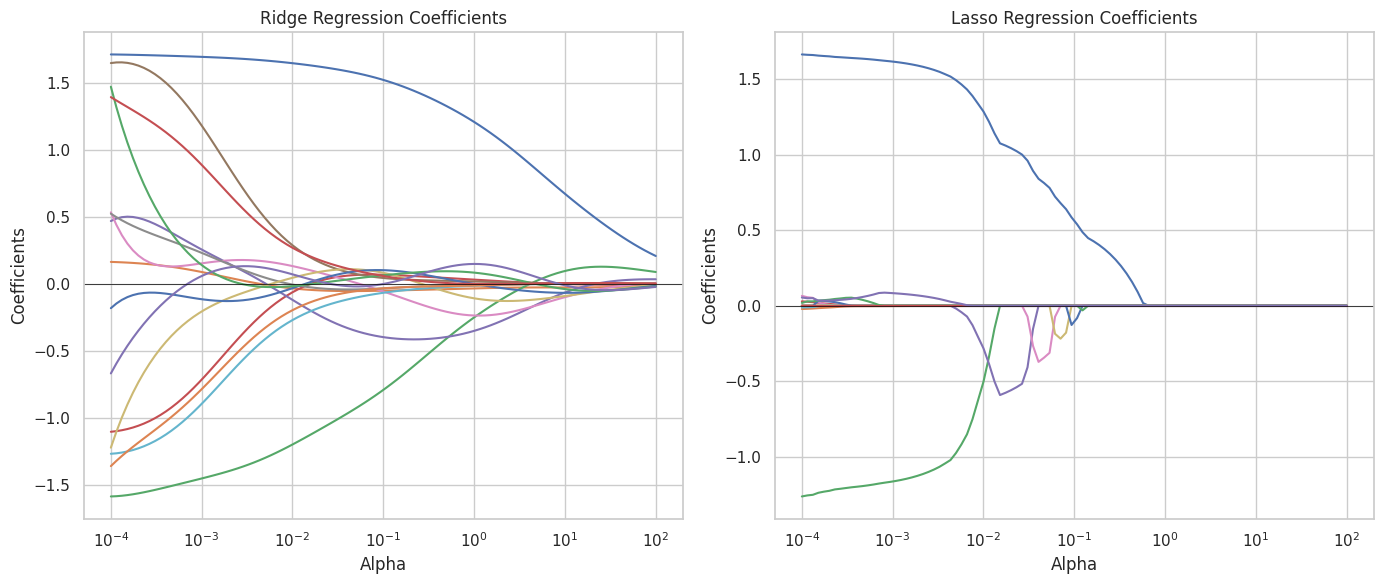

In [2]:
# Создаем полиномиальные признаки высокой степени
poly = PolynomialFeatures(degree=15, include_bias=False)
# Получаем 15 признаков из 1 исходного: x, x², x³, ..., x¹⁵

X_train_poly = poly.fit_transform(X_train_syn)
X_test_poly = poly.transform(X_test_syn)

# Масштабируем признаки (Критично для регуляризации!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

"""
Почему масштабирование обязательно:
- Ridge/Lasso штрафуют величину коэффициентов
- Без масштабирования признак с большим диапазоном значений получит меньший коэффициент и меньший штраф
- Это приведёт к несправедливой регуляризации
"""

# Диапазон альфа (логарифмическая шкала)
alphas = np.logspace(-4, 2, 100)

ridge_coefs = []
lasso_coefs = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_scaled, y_train_syn)
    ridge_coefs.append(ridge.coef_)

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train_scaled, y_train_syn)
    lasso_coefs.append(lasso.coef_)

# Визуализация путей коэффициентов
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Ridge
ax[0].plot(alphas, ridge_coefs)
ax[0].set_xscale('log')
ax[0].set_title('Ridge Regression Coefficients')
ax[0].set_xlabel('Alpha')
ax[0].set_ylabel('Coefficients')
ax[0].axhline(0, color='black', linewidth=0.5)

# Lasso
ax[1].plot(alphas, lasso_coefs)
ax[1].set_xscale('log')
ax[1].set_title('Lasso Regression Coefficients')
ax[1].set_xlabel('Alpha')
ax[1].set_ylabel('Coefficients')
ax[1].axhline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

Показать, как меняются 15 коэффициентов модели при увеличении штрафа α.

### 📊 Какие результаты мы видим

- Два графика: Ridge Coefficients и Lasso Coefficients
- Ось X: Alpha (логарифмическая шкала)
- Ось Y: Значения коэффициентов

### Визуальная интерпретация:
- Ridge: Все 15 линий плавно сходятся к нулю, но никогда не достигают его
- Lasso: Линии "падают" на ноль и остаются там (вертикальный излом)

### 🧠 Комментарий:
На графике Lasso вы увидите, что линии "падают" на ноль и остаются там. Это свойство $L_1$-нормы. В Ridge линии просто приближаются к нулю. Это делает Lasso мощным инструментом для интерпретации моделей.

##Выводы
 "Различие обусловлено геометрией штрафных функций:
- L1-норма имеет 'углы' в точках обнуления, что позволяет решению достигать нуля точно.
- L2-норма имеет гладкую сферическую форму, поэтому коэффициенты лишь асимптотически приближаются к нулю."

---

## 💻 Практический блок 3: Автоматический подбор (GridSearchCV)

Вместо ручного перебора используем кросс-валидацию.

In [3]:
# Настройка пайплайна для подбора
pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', Ridge()) # Будем менять и модель, и альфа в сетке
])

# Параметрическая сетка
param_grid = {
    'reg': [Ridge(), Lasso(max_iter=10000)],
    'reg__alpha': np.logspace(-4, 2, 20)
}

# GridSearch с 5-кратной кросс-валидацией
grid_search = GridSearchCV(pipe, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train_syn, y_train_syn)

print(f"Лучший счет (MSE): {-grid_search.best_score_:.4f}")
print(f"Лучшие параметры: {grid_search.best_params_}")

# Сравнение лучшей модели с базовой
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_syn)
print(f"Test MSE Best Model: {mean_squared_error(y_test_syn, y_pred_best):.4f}")

Лучший счет (MSE): 0.0105
Лучшие параметры: {'reg': Ridge(), 'reg__alpha': np.float64(0.0001)}
Test MSE Best Model: 0.0064


---

## 📚 Теоретический блок 3: Реальные данные и Мультиколлинеарность

**Мультиколлинеарность** — это ситуация, когда признаки сильно коррелируют друг с другом.
*   **Проблема:** В обычной линейной регрессии (OLS) это приводит к огромным дисперсиям оценок коэффициентов (модель становится неустойчивой).
*   **Решение:** Ridge-регуляризация стабилизирует решение, жертвуя небольшой несмещенностью ради снижения дисперсии.

---

## 💻 Практический блок 4: Анализ на датасете Diabetes


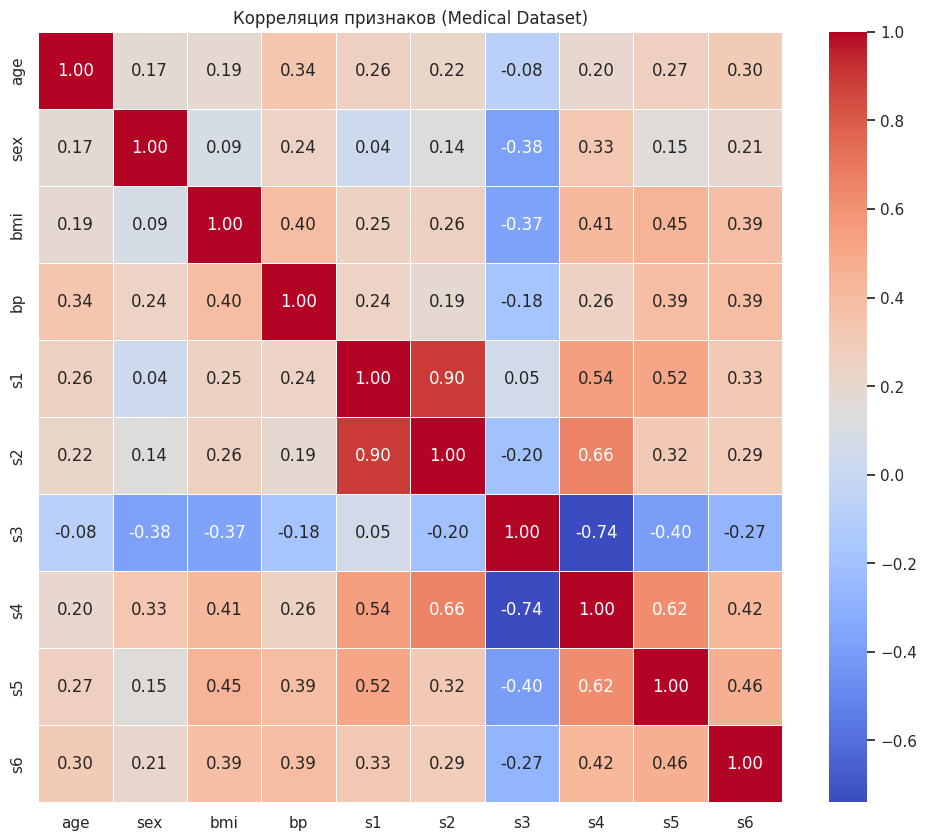

    Model        R²          MSE  Non-Zero Coefs
0  Linear  0.517748  2859.696348              10
1   Ridge  0.517582  2860.682243              10
2   Lasso  0.517376  2861.903917               9

Лучшая модель по R²: Linear


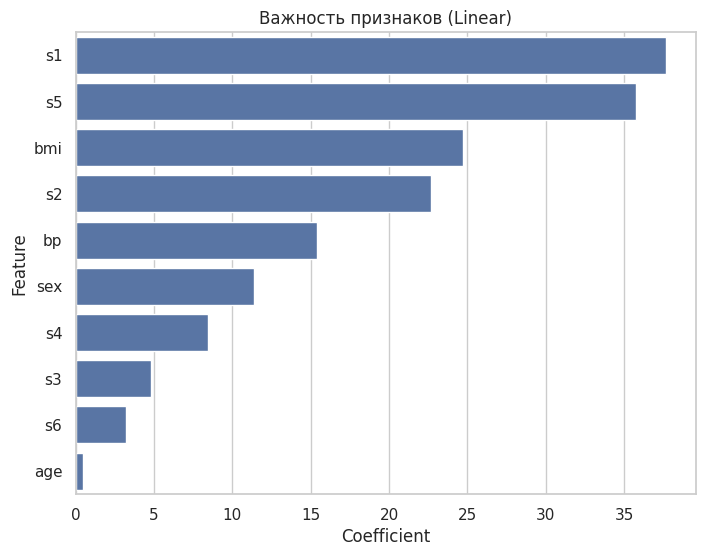

In [4]:
# Загрузка медицинских данных
diabetes = load_diabetes()
X_real = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_real = diabetes.target

# 1. Тепловая карта корреляций
plt.figure(figsize=(12, 10))
corr_matrix = X_real.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Корреляция признаков (Medical Dataset)')
plt.show()

# 2. Сравнение моделей
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1, max_iter=10000)
}

results = []

for name, model in models.items():
    # Пайплайн с масштабированием
    pipe = Pipeline([('scaler', StandardScaler()), ('reg', model)])
    pipe.fit(X_real, y_real)

    y_pred = pipe.predict(X_real)
    r2 = r2_score(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)

    # Получаем коэффициенты
    coefs = pipe.named_steps['reg'].coef_
    non_zero = np.sum(coefs != 0)

    results.append({
        'Model': name,
        'R²': r2,
        'MSE': mse,
        'Non-Zero Coefs': non_zero
    })

results_df = pd.DataFrame(results)
print(results_df)

# 3. Анализ важности признаков для лучшей модели (по R²)
best_model_name = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"\nЛучшая модель по R²: {best_model_name}")

# Визуализация коэффициентов лучшей модели
best_pipe = Pipeline([('scaler', StandardScaler()), ('reg', models[best_model_name])])
best_pipe.fit(X_real, y_real)
coefs = best_pipe.named_steps['reg'].coef_

feat_importance = pd.DataFrame({
    'Feature': X_real.columns,
    'Coefficient': np.abs(coefs)
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x='Coefficient', y='Feature', data=feat_importance)
plt.title(f'Важность признаков ({best_model_name})')
plt.show()

---

## 💻 Практический блок 5: Устойчивость отбора признаков (Stability Check)

Lasso может быть чувствителен к шуму в данных. Проверим, какие признаки отбираются стабильно.


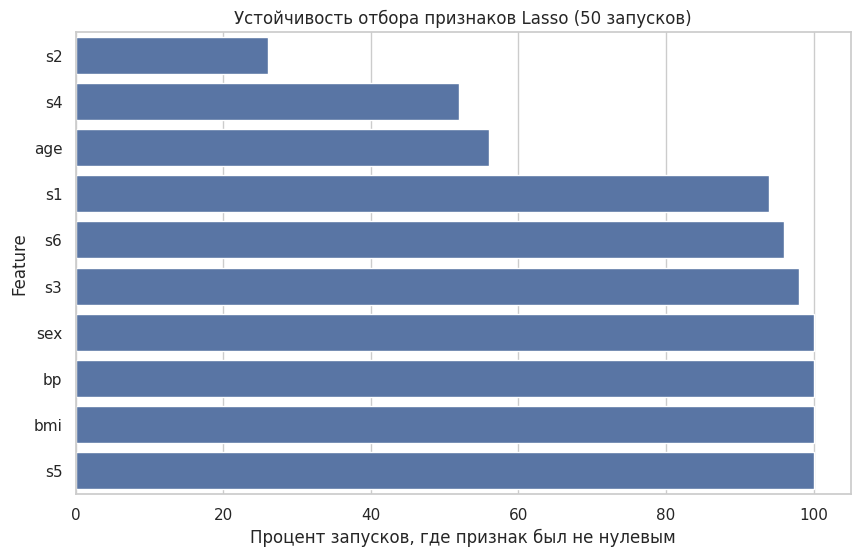

Признаки, отобранные более чем в 80% случаев (Стабильные):
['sex' 'bmi' 'bp' 's1' 's3' 's5' 's6']


In [6]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LassoCV

n_runs = 50
selected_features_count = {col: 0 for col in X_real.columns}

for i in range(n_runs):
    # Разные разбиения данных
    X_tr, X_te, y_tr, y_te = train_test_split(X_real, y_real, test_size=0.2, random_state=i)

    # Подбор альфа через кросс-валидацию внутри цикла для честности
    lasso_cv = LassoCV(cv=5, random_state=i, max_iter=10000)
    pipe_stab = Pipeline([('scaler', StandardScaler()), ('reg', lasso_cv)])
    pipe_stab.fit(X_tr, y_tr)

    coefs = pipe_stab.named_steps['reg'].coef_

    for j, col in enumerate(X_real.columns):
        if coefs[j] != 0:
            selected_features_count[col] += 1

# Визуализация стабильности
stability_df = pd.DataFrame(list(selected_features_count.items()), columns=['Feature', 'Selection_Frequency'])
stability_df['Frequency_%'] = (stability_df['Selection_Frequency'] / n_runs) * 100

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency_%', y='Feature', data=stability_df.sort_values('Frequency_%'))
plt.title(f'Устойчивость отбора признаков Lasso ({n_runs} запусков)')
plt.xlabel('Процент запусков, где признак был не нулевым')
plt.show()

print("Признаки, отобранные более чем в 80% случаев (Стабильные):")
print(stability_df[stability_df['Frequency_%'] > 80]['Feature'].values)

---

## 📝 Выводы и Рекомендации

На основе проведенного эксперимента можно сформулировать следующие рекомендации:

| Цель задачи | Рекомендуемая модель | Обоснование |
| :--- | :--- | :--- |
| **Максимальная точность** | **Ridge** или **ElasticNet** | Ridge лучше справляется с мультиколлинеарностью, не отбрасывая информацию. |
| **Интерпретируемость** | **Lasso** | Позволяет получить разреженную модель (мало признаков), легче объяснить бизнесу. |
| **Много шума / признаков** | **Lasso** | Выполняет автоматический отбор признаков (Feature Selection). |
| **Сильная корреляция признаков** | **Ridge** | Lasso может случайно выбрать один из коррелирующих признаков, Ridge распределит вес между ними. |

---

## 🎓 Задания для самостоятельного решения

Попробуйте выполнить следующие задания, чтобы закрепить материал. Не забудьте документировать свои выводы в ячейках Markdown.

### Задание 1: Сравнение ElasticNet
Реализуйте модель **ElasticNet** (комбинация $L_1$ и $L_2$ регуляризации).
*   Используйте `ElasticNetCV` для подбора параметров `l1_ratio` и `alpha`.
*   Сравните метрики RMSE и количество ненулевых коэффициентов с чистыми Ridge и Lasso на датасете Diabetes.
*   *Подсказка:* `l1_ratio=1` это Lasso, `l1_ratio=0` это Ridge.

### Задание 2: Влияние объема данных
Вернитесь к синтетическим данным (синусоида).
*   Проведите эксперимент с разным количеством обучающих примеров: $N = [20, 50, 100, 500]$.
*   Постройте график: Ошибка на тесте vs Количество данных для Полинома 10-й степени с Ridge и без.
*   *Вопрос:* Помогает ли регуляризация, когда данных мало?

### Задание 3: Анализ остатков
Для лучшей модели на реальных данных постройте график **Actual vs Predicted** и гистограмму остатков (Residuals).
*   Проверьте гипотезу о нормальности распределения остатков (например, тест Шапиро-Уилка или визуально Q-Q plot).
*   Если остатки не нормальны, о чем это может говорить? (Подсказка: нелинейность, гетероскедастичность).

---

## 📚 Рекомендуемая литература и цитирование

Для оформления отчетов и курсовых работ используйте следующие источники.

**Книги:**
1.  Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. Springer. (Глава 3: Linear Methods for Regression).
2.  Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

**Пример цитирования (APA Style):**
> Для борьбы с переобучением в линейных моделях широко применяется регуляризация, которая добавляет штраф за сложность модели к функции потерь (Hastie et al., 2009).

**Пример цитирования (MLA Style):**
> Hastie, Trevor, et al. *The Elements of Statistical Learning*. Springer, 2009.

> ⚠️ **Академическая честность:** При выполнении заданий самостоятельно пишите код своими руками. Использование готовых решений без понимания логики лишает вас возможности научиться диагностировать модели в реальных проектах. Если вы используете код из документации sklearn, указывайте это в комментариях.


---

### 💡 Дополнительные советы по работе в Colab
1.  **Сохраняйте версию:** `File -> Save a copy in Drive`, чтобы не потерять прогресс.
2.  **Секреты:** Если используете приватные данные, не выкладывайте ноутбук в публичный доступ GitHub без очистки чувствительной информации.
3.  **Воспроизводимость:** Всегда фиксируйте `random_state` в функциях разделения данных и моделях, чтобы ваши результаты можно было проверить.

Удачи в изучении машинного обучения! Если возникнут вопросы по интерпретации графиков или ошибкам в коде, обращайтесь.


---

## Советы по выполнению

1. **Экспериментируйте с learning rate**: Попробуйте значения от 0.001 до 0.1
2. **Следите за переобучением**: Сравнивайте метрики на train и test выборках
3. **Используйте визуализацию**: Графики помогают понять поведение модели
4. **Сохраняйте результаты**: Используйте pickle или joblib для сохранения моделей
5. **Документируйте код**: Добавляйте комментарии к сложным участкам

---

**Удачи в выполнении практической работы! **